# Numpy

In [1]:
import numpy as np
import time

In [2]:
arr= np.array([[1, 2, 3], [4, 5, 6]])
print(arr.shape)
print(arr.ndim)
print(arr.dtype)

(2, 3)
2
int64


In [4]:
py_list= list(range(1_00_000))
py_result= []
start_time= time.time()
for i in py_list:
    py_result.append(i+5)
end_time= time.time()
print('Python List Time:', end_time - start_time)

Python List Time: 0.047997474670410156


In [5]:
np_array= np.arange(1_000_000)
start_time= time.time()
np_result= np_array + 5
end_time= time.time()
print('Numpy Array Time:', end_time - start_time)

Numpy Array Time: 0.007998943328857422


In [6]:
print(np.eye(3))

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [7]:
print(np.diag([1, 2, 3]))

[[1 0 0]
 [0 2 0]
 [0 0 3]]


In [8]:
np.array([1, 2, 3], dtype=float)

array([1., 2., 3.])

In [9]:
arr= np.array([1.2, 2.3, 4.5])
print(arr.astype(int))

[1 2 4]


## Generate the random numbers:

In [1]:
import numpy as np

In [11]:
# Simulate 100k coin flips
rng= np.random.default_rng(seed=42)
flips= rng.integers(0, 2, size=100000) # 0= tails, 1= head
prob_head= np.mean(flips)
print("Estimated probability of heads:", prob_head)

Estimated probability of heads: 0.50089


In [13]:
import time
import numpy as np

# Python list comprehension
start = time.time()
squares = [i**2 for i in range(100000)]
end = time.time()

print("Loop time:", end - start)

# NumPy vectorized operation
start = time.time()
arr = np.arange(100000)
squares_np = arr**2
end = time.time()

print("Vectorized time:", end - start)

Loop time: 0.03626585006713867
Vectorized time: 0.00799417495727539


# Outliers

In [ ]:
# IQR method used for time series data and other types of the data we use the z-score method
Q1= df['revenue'].qurtile(0.25)
Q3= df['revenue'].qurtile(0.75)
IQR= Q3 - Q1

lower_qurtile= Q1 - 1.5 * IQR
upper_qurtile= Q3 + 1.5 * IQR

outlier_iqr= df[(df['revenus'] < lower_qurtile) | (df['revenue'] > upper_qurtile)]
outlier_iqr.shape# this line tell us the how many outliers are in dataset

In [ ]:
outlier_iqr[['revenus', 'any col name']].head()

In [ ]:
df= df[(df['revenus'] >= lower_qurtile) & (df['revenus'] <= upper_qurtile)] # this line will remove the outlier
df.shape

# Matplotlib

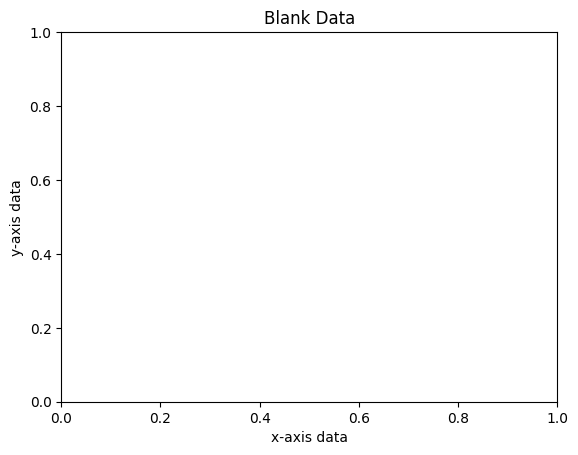

In [3]:
import matplotlib.pyplot as plt

# OO-workflow
fig, ax= plt.subplots()

# label axes
ax.set_title('Blank Data')
ax.set_xlabel('x-axis data')
ax.set_ylabel('y-axis data')

# Save the PNG
fig.savefig('blank_data.png', dpi=100)

plt.show()

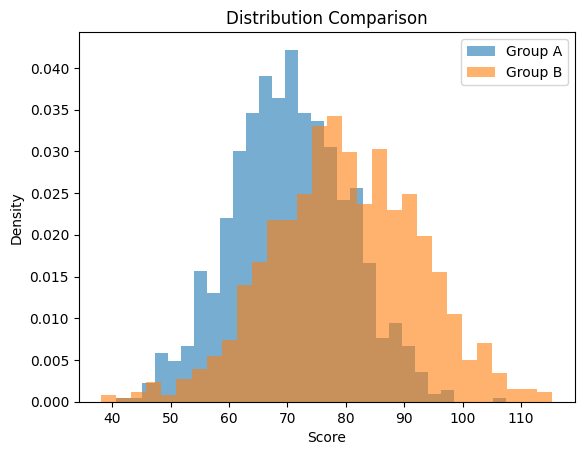

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

group_a= np.random.normal(70, 10, 1000)# 70 is mean 10 is std and 1000 is random value
group_b= np.random.normal(80, 12, 1000)

plt.hist(group_a, bins=30, density=True, alpha=0.6, label='Group A')
plt.hist(group_b, bins=30, density=True, alpha=0.6, label='Group B')# Transperancy is alpha 60%

plt.xlabel('Score')
plt.ylabel('Density')
plt.title('Distribution Comparison')
plt.legend()
plt.show()

In [ ]:
# Half show the correlation matrixs
# Masking the upper Triangle
import numpy as np

mask= np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask, 
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap (Masked)')
plt.show()

# One-Hot Encoding

In [5]:
import pandas as pd
df= pd.DataFrame({
    'City': ['Lahore', 'Karachi', 'Islamabad', 'Rawalpindi', 'Karachi', "Lahore"],
    'Segment': ['A', 'B', 'C', 'D', 'A', 'D'],
    'Sales': [200, 320, 430, 330, 290, 443]
})

print(df)

         City Segment  Sales
0      Lahore       A    200
1     Karachi       B    320
2   Islamabad       C    430
3  Rawalpindi       D    330
4     Karachi       A    290
5      Lahore       D    443


In [7]:
# one-hot encoding
encoded= pd.get_dummies(df, columns=['City', 'Segment'], drop_first=False)
print(encoded)

   Sales  City_Islamabad  City_Karachi  City_Lahore  City_Rawalpindi  \
0    200           False         False         True            False   
1    320           False          True        False            False   
2    430            True         False        False            False   
3    330           False         False        False             True   
4    290           False          True        False            False   
5    443           False         False         True            False   

   Segment_A  Segment_B  Segment_C  Segment_D  
0       True      False      False      False  
1      False       True      False      False  
2      False      False       True      False  
3      False      False      False       True  
4       True      False      False      False  
5      False      False      False       True  


# Scikit learn use for ordinal encoding

In [8]:
from sklearn.preprocessing import OrdinalEncoder

df2= pd.DataFrame({
    'Size': ['Small', 'Medium', 'Large', 'Small', 'Large', 'Medium']
})

print(df2)

     Size
0   Small
1  Medium
2   Large
3   Small
4   Large
5  Medium


In [9]:
encoder= OrdinalEncoder(categories=[['Small', 'Medium', 'Large']])
df2['Size_encoder']= encoder.fit_transform(df2[['Size']])
print(df2)

     Size  Size_encoder
0   Small           0.0
1  Medium           1.0
2   Large           2.0
3   Small           0.0
4   Large           2.0
5  Medium           1.0


### scaling after check the min, max, mid value together

In [ ]:
df.loc[
    df['monthly_bil'].idxmin(),
    df['monthly_bil'].idxmax(),
    df['monthly_bil'].sort_values().index[len(df//2)],
    ['montly_bill', 'bill_minmax']
]

In [ ]:
#  Data Leakage WRONG (Scaling before split)
df_scaled_wrong= (df['monthly_income'] - df['monthly_income'].mean()) / df['montly_income'].std()
df_scaled_wrong.head()

# Feature Transformation
* (used for outlier, and skewed data)
* method for transform(log transform, Box-Cox/ YeoJohnson)
* outlier handle(clipping, Winsorization)

In [ ]:
# Applying the log_transformation
df['income_log']= np.log1p(df['income_log'])


# Futher plot the data
import seaborn as sns
sns.set(style='whitegrid')
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['monthly_income'], kde=True, bins=30)
plt.title('Monthly Income (log transformed)')

plt.tight_layout()
plt.show()

# Styling of EDA:

In [ ]:
print("=== DATASET BASIC INFORMATION ===")
print(f'Dataset Diamensions: {df.shape[0]} rows X {df.shape[1]} columns')
print("\nColumn Names and Data Types:")
print(df.dtypes)

In [ ]:
# Ensure numeric columns are properly formatted
numeric_col= ['Sales', 'Quantity', 'Profit']
for col in numeric_col:
    df[col]= pd.to_numeric(df[col], errors='coerce')

print(f'\nRange of data: {df['Date'].min()} to {df['Date'].max()}')


# Summary
print('=== Statistical Summary ===')
print("Descriptive Statistical for Numerical Columns")
print(df[['', '', '']].describe())


print('\nCategory-wise Summary:')
category_summary= df.groupby('Category').agg({
    'Sale':['count', 'sum', 'mean', 'std'],
    'Profit': ['sum', 'mean'],
    'Quantity': ['sum', 'mean']
}).round(2)
print(category_summary)

## Removing outliers:

In [ ]:
# Clipping outliers to the 90th percentile
qu_limit= df['loan_amount'].quantile(0.90)
ql_limit= df['loan_amount'].quantile(0.05)
df['loan_cleaned_amount']= df['loan_amount'].clip(upper=qu_limit, lower=ql_limit)

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['loan_clean_amount'])
plt.title('------')
plt.show()

# Linear Regression(Gredient Decent)

In [3]:
import numpy as np

learning_rate= 0.01 # step size
epochs=5 # num of iteration
X= np.array([1, 2, 3, 4, 5])# input data
Y= np.array([3, 2, 1, 4, 6])# target data

m, b= 0.0, 0.0 # initial parameters
n=len(X) # no of data points

for i in range(epochs):
    y_pred=m*X + b
    cost= ((y_pred - Y) ** 2).mean()
    derivative_m= (-2/n) * sum(X * Y- y_pred)
    derivative_b= (-2/n) * sum( Y- y_pred)
    m -= learning_rate * derivative_m
    b -= learning_rate * derivative_b
    print(f'Epoch {i+1}/{epochs}, Cost: {cost}, m: {m}, b: {b}')

Epoch 1/5, Cost: 13.2, m: 0.22400000000000003, b: 0.064
Epoch 2/5, Cost: 8.414848, m: 0.43328, b: 0.11327999999999999
Epoch 3/5, Cost: 5.1419072512, m: 0.6290176000000001, b: 0.1490176
Epoch 4/5, Cost: 3.0932020759756798, m: 0.812296192, b: 0.172296192
Epoch 5/5, Cost: 2.029365031038616, m: 0.9841124966400001, b: 0.18411249663999998


# Decision Tree

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [5]:
# Create a toy dataset
X, y= make_moons(n_samples=500, noise=0.25, random_state=42)

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=30, random_state=42)

In [7]:
# Train tree with different depth
depth= list(range(1, 15))
train_acc= []
test_acc= []

for d in depth:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))


test_acc

[0.7666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.8,
 0.9333333333333333,
 0.9,
 0.8333333333333334,
 0.8333333333333334,
 0.8333333333333334,
 0.8333333333333334,
 0.8333333333333334,
 0.8333333333333334,
 0.8333333333333334,
 0.8333333333333334]

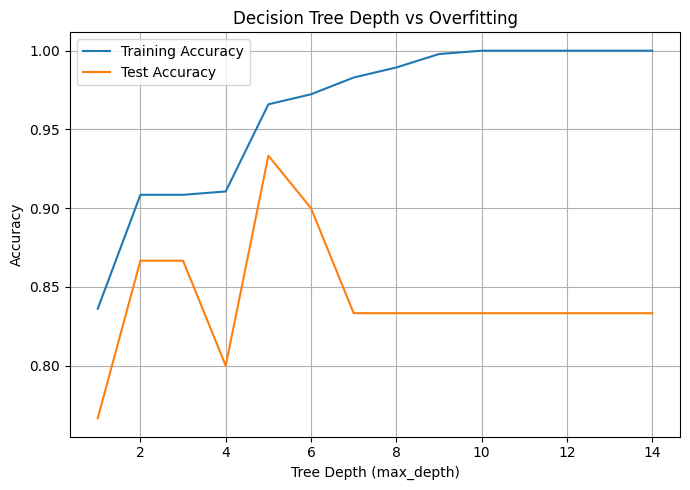

In [8]:
# plot the performance vs depth 
plt.figure(figsize=(7, 5))
plt.plot(depth, train_acc, label='Training Accuracy')
plt.plot(depth, test_acc, label='Test Accuracy')
plt.xlabel('Tree Depth (max_depth)')
plt.ylabel('Accuracy')
plt.title('Decision Tree Depth vs Overfitting')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# print key observation
best_depth= depth[np.argmax(test_acc)]
print(f'Best depth based on the test accuracy:{best_depth}')

Best depth based on the test accuracy:5
